In [1]:
import osmnx as ox
import numpy as np
import networkx as nx
import geopandas as gpd
import pandas as pd
import momepy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from shapely.geometry import Point, MultiLineString
from shapely.ops import linemerge
import sys, math, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from dgdc.dual_conti import clean_chains, new_angles, merged_G_angle

## Fetch a small area of Frederiksberg

## Run the DGDC pipeline step-by-step

In [2]:
from shapely.geometry import box as shapely_box

T_BUFFER = 10
A_THRESH = 20
np.random.seed(4)

place_name = 'Frederiksberg Municipality, Denmark'
G_full = ox.graph_from_place(place_name, network_type='all')

# All edges in UTM
all_edges = ox.graph_to_gdfs(ox.convert.to_undirected(G_full), nodes=False)
all_edges = all_edges.set_crs('epsg:4326').to_crs(all_edges.set_crs('epsg:4326').estimate_utm_crs())

# Sample a random 500x500 m bbox
# (100m is too small — a typical Frederiksberg block is ~150m, so a 100m window
#  likely captures only one road with no branching and an empty dual graph)
AREA_M = 500
minx, miny, maxx, maxy = all_edges.total_bounds
cx_rand = np.random.uniform(minx + AREA_M/2, maxx - AREA_M/2)
cy_rand = np.random.uniform(miny + AREA_M/2, maxy - AREA_M/2)
bbox_poly = shapely_box(cx_rand - AREA_M/2, cy_rand - AREA_M/2,
                        cx_rand + AREA_M/2, cy_rand + AREA_M/2)

# Keep every edge that intersects the bbox (pipeline will split at intersections)
shape_df = all_edges[all_edges.intersects(bbox_poly)].copy()
shape_df['edgeUID'] = shape_df.index
print(f'Edges intersecting {AREA_M}×{AREA_M} m area: {len(shape_df)}')

# ── split at intersections ────────────────────────────────────────────────────
shape_df = shape_df.reset_index().explode('geometry')
u = shape_df.union_all()
out = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries(u, crs=shape_df.crs).explode()
).reset_index(drop=True)
shape_exploded = out.sjoin(
    shape_df[['osmid', 'geometry', 'edgeUID']], how='left', predicate='intersects'
).drop_duplicates(subset=['geometry']).reset_index(drop=True)
shape_exploded['id'] = shape_exploded.index

# ── clean chains ──────────────────────────────────────────────────────────────
G_primal = momepy.gdf_to_nx(shape_exploded, approach='primal')
G_primal = clean_chains(G_primal)
_, lines = momepy.nx_to_gdf(G_primal)
print(f'Street segments after chain cleaning: {len(lines)}')

# ── dual graph (unmerged) ─────────────────────────────────────────────────────
G_dual = momepy.gdf_to_nx(lines, approach='dual', multigraph=False, angles=False)
G_dual = new_angles(G_dual, touch_buffer=T_BUFFER)
centroids = {n: G_dual.nodes[n]['geometry'].centroid for n in G_dual.nodes}
print(f'Dual graph: {G_dual.number_of_nodes()} nodes, {G_dual.number_of_edges()} edges')

# ── merged dual graph ─────────────────────────────────────────────────────────
H = merged_G_angle(G_dual, thresh=A_THRESH, attr='new_angle', enforce_degree2=False)
df_nodes = pd.DataFrame.from_dict(dict(H.nodes(data=True)), orient='index')
gdf_merged = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs=lines.crs)
degree_map = dict(H.degree())
gdf_merged['degree'] = gdf_merged.index.map(degree_map)
print(f'Merged dual: {len(gdf_merged)} continuity groups')


Edges intersecting 500×500 m area: 256
Street segments after chain cleaning: 230
Dual graph: 230 nodes, 377 edges
Merged dual: 115 continuity groups


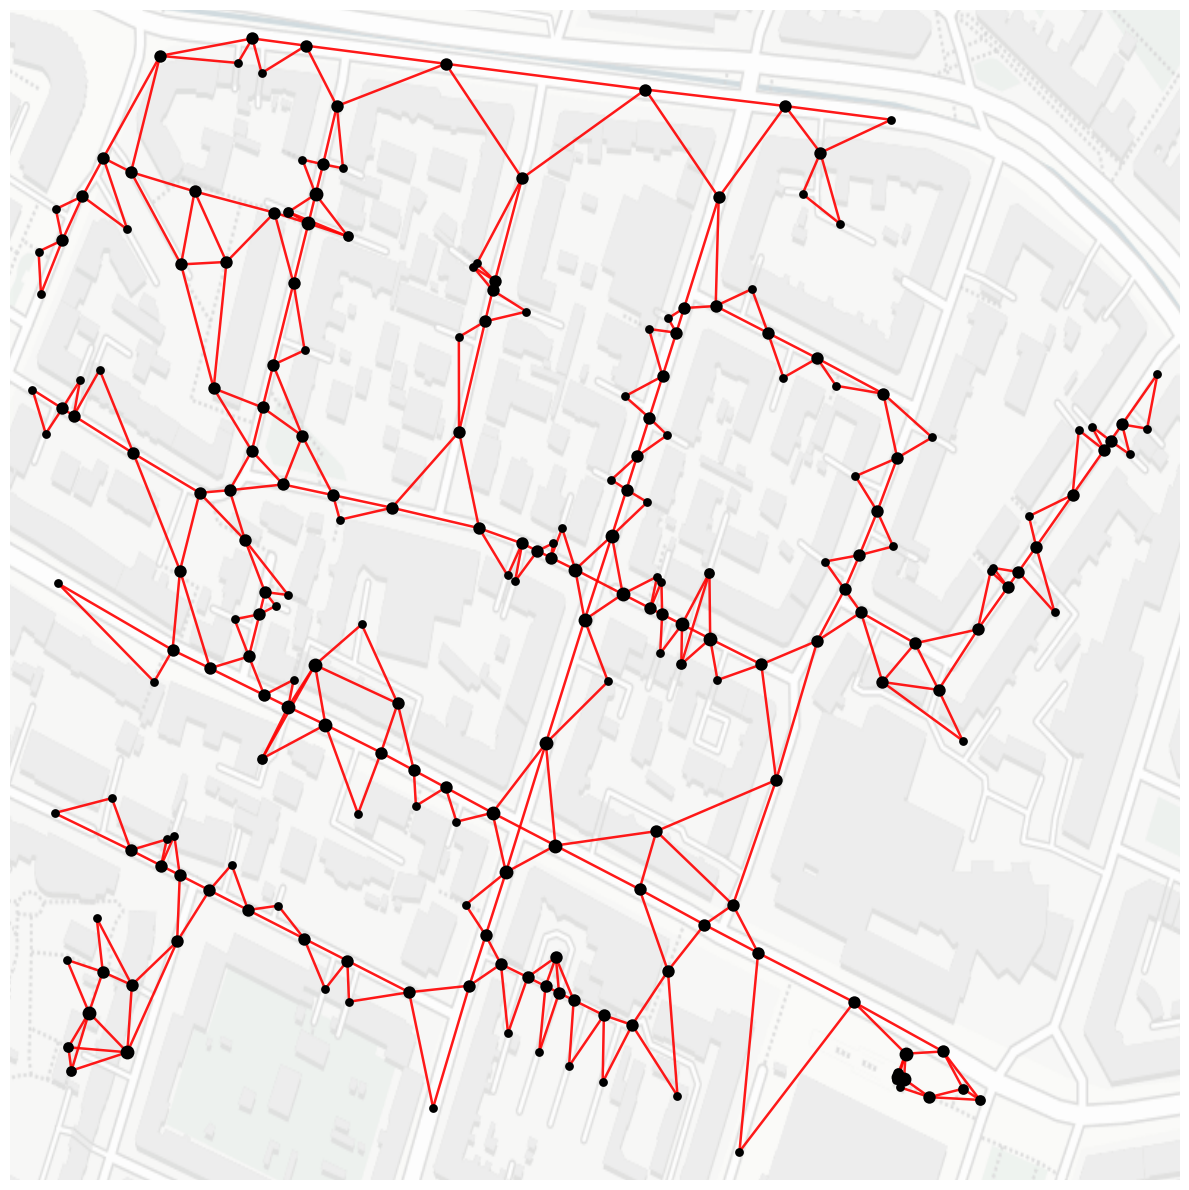

In [3]:
import contextily as cx

fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
ax.axis('off')

crs_utm  = lines.crs
crs_wm   = 'epsg:3857'
lines_wm = lines.to_crs(crs_wm)

# View extent from the actual street segments (where the nodes live), with padding
x0, y0, x1, y1 = lines_wm.total_bounds
pad = max(x1 - x0, y1 - y0) * 0.1
ax.set_xlim(x0 - pad, x1 + pad)
ax.set_ylim(y0 - pad, y1 + pad)

cx.add_basemap(ax, crs=crs_wm, source=cx.providers.CartoDB.PositronNoLabels,
               zoom='auto', attribution=False)

proj = lambda x, y: gpd.GeoSeries([Point(x, y)], crs=crs_utm).to_crs(crs_wm).iloc[0].coords[0]

dual_degrees = dict(G_dual.degree())
size_scale   = 20

for u_n, v_n in G_dual.edges():
    cu, cv = centroids[u_n], centroids[v_n]
    x1_, y1_ = proj(cu.x, cu.y)
    x2_, y2_ = proj(cv.x, cv.y)
    ax.plot([x1_, x2_], [y1_, y2_], '-',
            color='red', linewidth=1.8, alpha=0.9, zorder=3, solid_capstyle='round')

for n in G_dual.nodes:
    c = centroids[n]
    x, y = proj(c.x, c.y)
    ax.scatter(x, y, s=dual_degrees[n] * size_scale, color='k', zorder=4, linewidths=0)

# ax.set_title('Dual graph', fontsize=13, fontweight='bold', pad=10)

# View extent derived from dual-graph node positions (tighter fit)
node_xs, node_ys = zip(*[proj(centroids[n].x, centroids[n].y) for n in G_dual.nodes])
x0, x1 = min(node_xs), max(node_xs)
y0, y1 = min(node_ys), max(node_ys)
pad = max(x1 - x0, y1 - y0) * 0.02   # 2 % padding
ax.set_xlim(x0 - pad, x1 + pad)
ax.set_ylim(y0 - pad, y1 + pad)

plt.tight_layout()
plt.show()

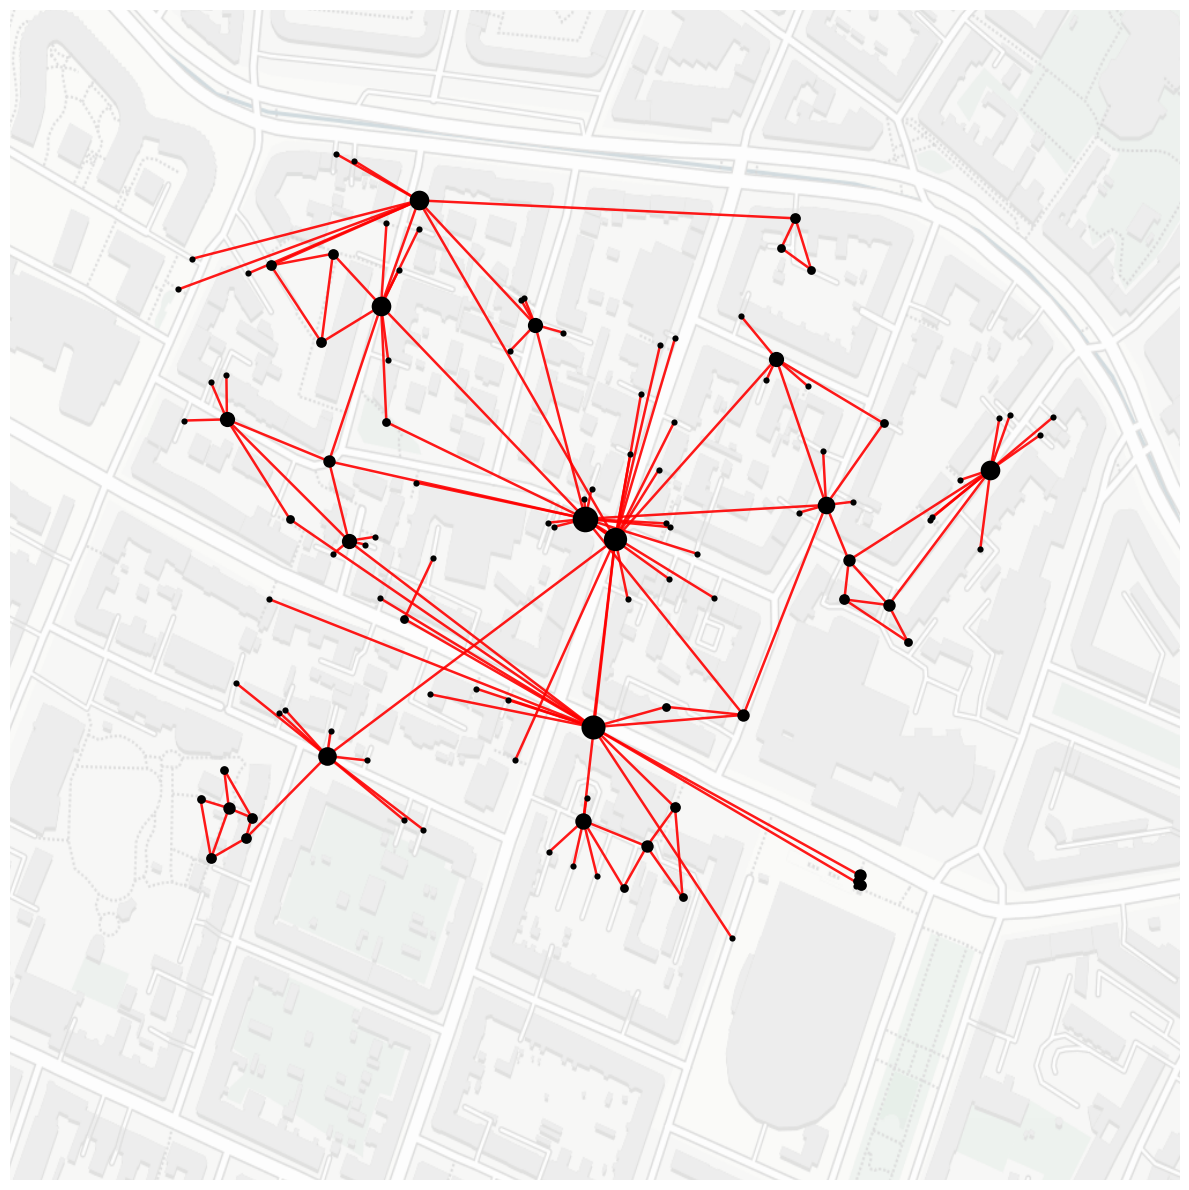

In [4]:
import contextily as cx

fig, ax = plt.subplots(figsize=(12, 12), dpi=100)
ax.axis('off')

crs_utm  = lines.crs
crs_wm   = 'epsg:3857'
lines_wm = lines.to_crs(crs_wm)

x0, y0, x1, y1 = lines_wm.total_bounds
pad = max(x1 - x0, y1 - y0) * 0.1
ax.set_xlim(x0 - pad, x1 + pad)
ax.set_ylim(y0 - pad, y1 + pad)

cx.add_basemap(ax, crs=crs_wm, source=cx.providers.CartoDB.PositronNoLabels,
               zoom='auto', attribution=False)

proj = lambda x, y: gpd.GeoSeries([Point(x, y)], crs=crs_utm).to_crs(crs_wm).iloc[0].coords[0]

degrees    = dict(H.degree())
size_scale = 20

for u_n, v_n in H.edges():
    x1_, y1_ = proj(*u_n)
    x2_, y2_ = proj(*v_n)
    ax.plot([x1_, x2_], [y1_, y2_], '-',
            color='red', linewidth=1.8, alpha=0.9, zorder=3, solid_capstyle='round')

for n in H.nodes:
    x, y = proj(*n)
    ax.scatter(x, y, s=degrees[n] * size_scale, color='k', zorder=4, linewidths=0)

ax.set_xlim(x0 - pad, x1 + pad)
ax.set_ylim(y0 - pad, y1 + pad)

# ax.set_title('Merged dual graph (DGDC)', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()
